Merging the Residual data to the data Returned from BLAST API

In [1]:
import pandas as pd

# Load both CSVs
df_props = pd.read_csv(
    "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_OK.csv"
)
df_resid = pd.read_csv(
    "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_residuals_centered.csv"
)

# Merge only the 'residual_centered' column from df_resid, matching on 'ztfname'
df_merged = df_props.merge(
    df_resid[["ztfname", "residual_centered"]],
    on="ztfname",
    how="left"  # keeps all rows from df_props
)

# Save to a new CSV
df_merged.to_csv(
    "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_with_residuals.csv",
    index=False
)

print("✅ Merged file saved successfully.")
print(f"Shape: {df_merged.shape}")

✅ Merged file saved successfully.
Shape: (1279, 52)


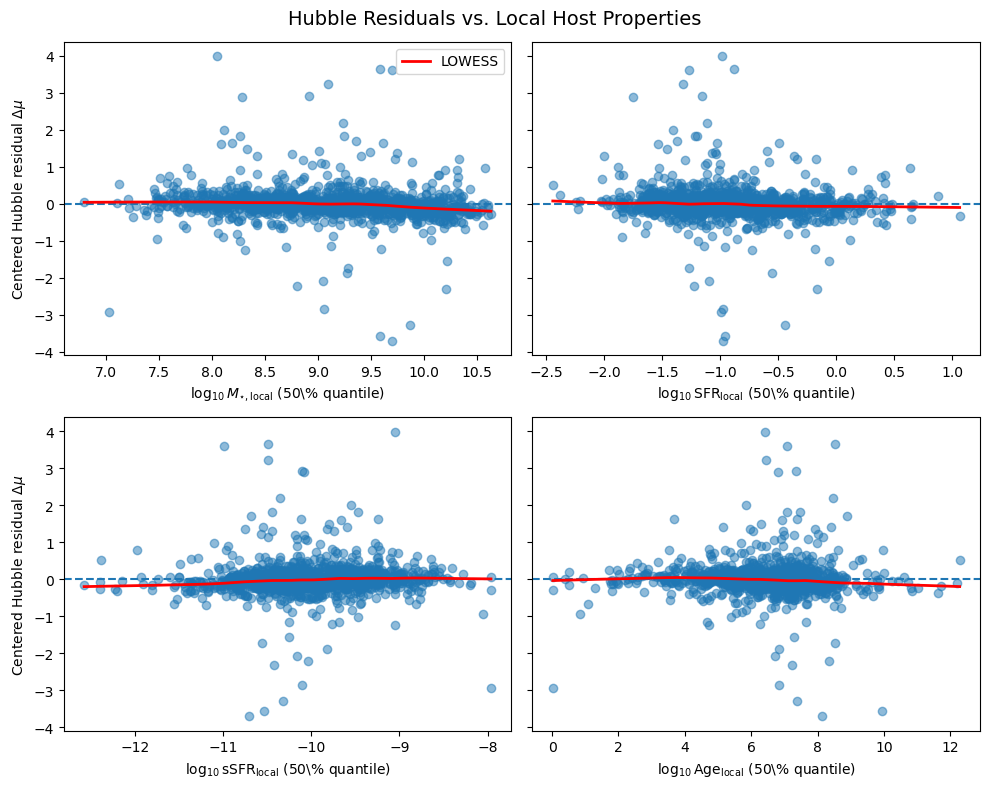

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm  # for LOWESS

# Load the merged file
df = pd.read_csv(
    "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_with_residuals.csv"
)

# Drop rows where residual_centered is NaN
df = df.dropna(subset=["residual_centered"])

# Convenience: LOWESS helper
lowess = sm.nonparametric.lowess

def add_lowess(ax, x, y, frac=0.3):
    """Add a LOWESS trend line to an axis."""
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        return  # not enough points to fit
    smoothed = lowess(y[mask], x[mask], frac=frac, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], linewidth=2, color="red", label="LOWESS")

# Set up 2x2 grid of scatter plots
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
fig.suptitle("Hubble Residuals vs. Local Host Properties", fontsize=14)

# 1) residual_centered vs blast_local_log_mass_50
ax = axes[0, 0]
x = df["blast_local_log_mass_50"]
y = df["residual_centered"]
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--")
add_lowess(ax, x, y, frac=0.3)
ax.set_xlabel(r"$\log_{10} M_{\star,\mathrm{local}}$ (50\% quantile)")
ax.set_ylabel(r"Centered Hubble residual $\Delta \mu$")

# 2) residual_centered vs blast_local_log_sfr_50
ax = axes[0, 1]
x = df["blast_local_log_sfr_50"]
y = df["residual_centered"]
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--")
add_lowess(ax, x, y, frac=0.3)
ax.set_xlabel(r"$\log_{10} \mathrm{SFR}_{\mathrm{local}}$ (50\% quantile)")

# 3) residual_centered vs blast_local_log_ssfr_50
ax = axes[1, 0]
x = df["blast_local_log_ssfr_50"]
y = df["residual_centered"]
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--")
add_lowess(ax, x, y, frac=0.3)
ax.set_xlabel(r"$\log_{10} \mathrm{sSFR}_{\mathrm{local}}$ (50\% quantile)")
ax.set_ylabel(r"Centered Hubble residual $\Delta \mu$")

# 4) residual_centered vs blast_local_log_age_50
ax = axes[1, 1]
x = df["blast_local_log_age_50"]
y = df["residual_centered"]
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--")
add_lowess(ax, x, y, frac=0.3)
ax.set_xlabel(r"$\log_{10} \mathrm{Age}_{\mathrm{local}}$ (50\% quantile)")

# Optional: show a legend in just one panel
axes[0, 0].legend()

plt.tight_layout()
plt.show()

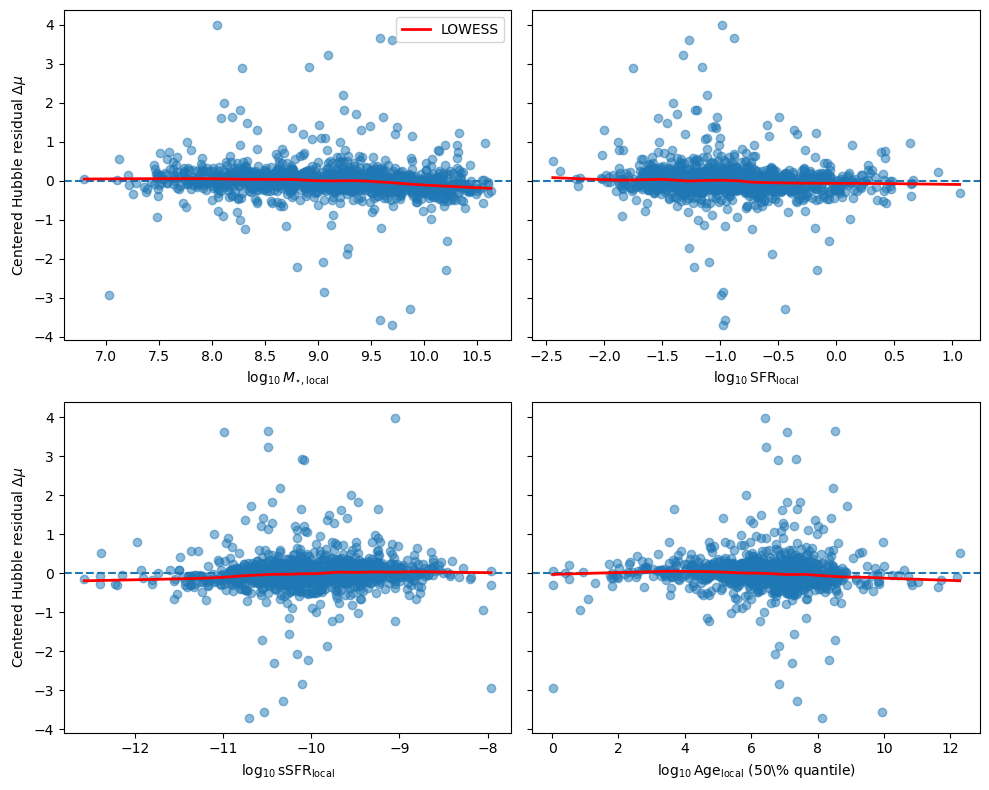

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr

# Load the merged file
df = pd.read_csv(
    "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_with_residuals.csv"
)

# Drop rows where residual_centered is NaN
df = df.dropna(subset=["residual_centered"])

# Convenience
lowess = sm.nonparametric.lowess

def add_lowess(ax, x, y, frac=0.3):
    """Add a LOWESS trend line to an axis."""
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        return None
    smoothed = lowess(y[mask], x[mask], frac=frac, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], linewidth=2, color="red", label="LOWESS")

def add_spearman(ax, x, y):
    """Compute Spearman correlation and annotate it."""
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        rho, pval = np.nan, np.nan
    else:
        rho, pval = spearmanr(x[mask], y[mask])
    ax.text(
        0.05, 0.95,
        f"ρ = {rho:.2f}\np = {pval:.2g}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )
    return rho, pval

# Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

# 1) residual_centered vs local log mass
ax = axes[0, 0]
x = df["blast_local_log_mass_50"]
y = df["residual_centered"]
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--")
add_lowess(ax, x, y, frac=0.3)
ax.set_xlabel(r"$\log_{10} M_{\star,\mathrm{local}}$")
ax.set_ylabel(r"Centered Hubble residual $\Delta \mu$")

# 2) residual_centered vs local log SFR
ax = axes[0, 1]
x = df["blast_local_log_sfr_50"]
y = df["residual_centered"]
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--")
add_lowess(ax, x, y, frac=0.3)
ax.set_xlabel(r"$\log_{10} \mathrm{SFR}_{\mathrm{local}}$")

# 3) residual_centered vs local log sSFR
ax = axes[1, 0]
x = df["blast_local_log_ssfr_50"]
y = df["residual_centered"]
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--")
add_lowess(ax, x, y, frac=0.3)
ax.set_xlabel(r"$\log_{10} \mathrm{sSFR}_{\mathrm{local}}$")
ax.set_ylabel(r"Centered Hubble residual $\Delta \mu$")

# 4) residual_centered vs local log age
ax = axes[1, 1]
x = df["blast_local_log_age_50"]
y = df["residual_centered"]
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--")
add_lowess(ax, x, y, frac=0.3)
ax.set_xlabel(r"$\log_{10} \mathrm{Age}_{\mathrm{local}}$ (50\% quantile)")

# Add legend
axes[0, 0].legend()

plt.tight_layout()
plt.show()

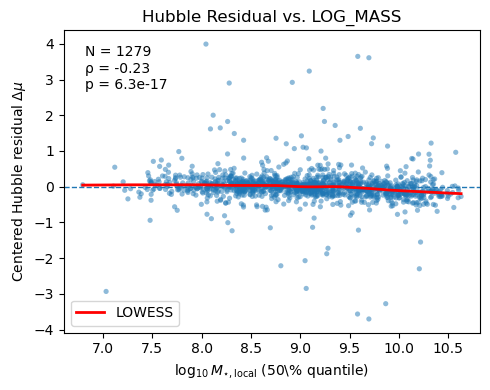

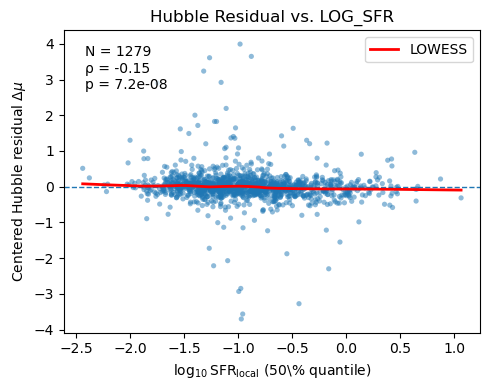

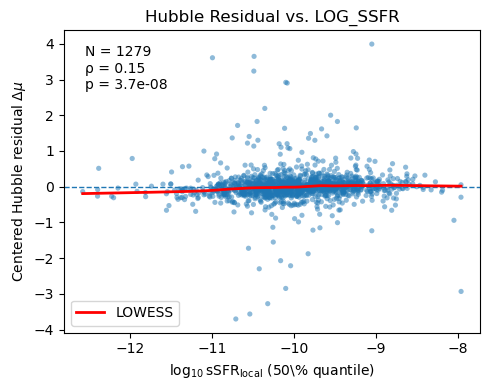

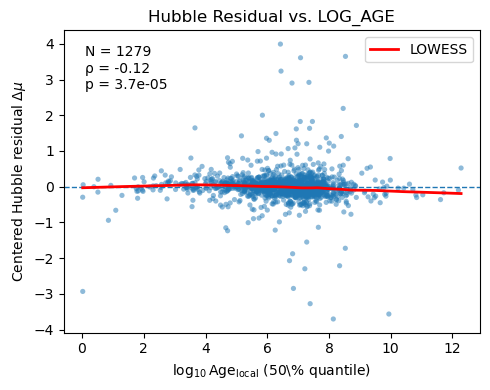

                     x_var       rho       p_value     N
0  blast_local_log_mass_50 -0.230800  6.317061e-17  1279
1   blast_local_log_sfr_50 -0.149929  7.157967e-08  1279
2  blast_local_log_ssfr_50  0.153105  3.741509e-08  1279
3   blast_local_log_age_50 -0.115121  3.678399e-05  1279


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr

# Load data
df = pd.read_csv(
    "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_with_residuals.csv"
)
df = df[np.isfinite(df["residual_centered"])].copy()

lowess = sm.nonparametric.lowess

def add_lowess(ax, x, y, frac=0.3, label="LOWESS"):
    """Add a LOWESS trend line."""
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        return None
    smoothed = lowess(y[mask], x[mask], frac=frac, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], linewidth=2, color="red", label=label)
    return smoothed

def add_spearman(ax, x, y):
    """Compute Spearman correlation and annotate it."""
    mask = np.isfinite(x) & np.isfinite(y)
    n = mask.sum()
    if n < 5:
        rho, pval = np.nan, np.nan
    else:
        rho, pval = spearmanr(x[mask], y[mask])
        if np.isnan(rho):
            rho, pval = np.nan, np.nan
    ax.text(
        0.05, 0.95,
        f"N = {n}\nρ = {rho:.2f}\np = {pval:.2g}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )
    return rho, pval, n

# List of panels to plot
panels = [
    ("blast_local_log_mass_50", r"$\log_{10} M_{\star,\mathrm{local}}$ (50\% quantile)"),
    ("blast_local_log_sfr_50",  r"$\log_{10} \mathrm{SFR}_{\mathrm{local}}$ (50\% quantile)"),
    ("blast_local_log_ssfr_50", r"$\log_{10} \mathrm{sSFR}_{\mathrm{local}}$ (50\% quantile)"),
    ("blast_local_log_age_50",  r"$\log_{10} \mathrm{Age}_{\mathrm{local}}$ (50\% quantile)"),
]

spearman_rows = []

# Create and show (or save) each plot individually
for col, xlabel in panels:
    x = df[col].values
    y = df["residual_centered"].values

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(x, y, alpha=0.5, s=14, edgecolors="none")
    ax.axhline(0, linestyle="--", linewidth=1)
    add_lowess(ax, x, y, frac=0.3)
    rho, p, n = add_spearman(ax, x, y)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"Centered Hubble residual $\Delta \mu$")
    ax.legend(loc="best")
    ax.set_title("Hubble Residual vs. " + col.replace("blast_local_", "").replace("_50", "").upper())

    plt.tight_layout()
    plt.show()  # or plt.savefig(f"{col}_residual_plot.png", dpi=300)
    plt.close(fig)

    spearman_rows.append({"x_var": col, "rho": rho, "p_value": p, "N": n})

# Collect stats in a summary table
spearman_table = pd.DataFrame(spearman_rows)
print(spearman_table)
# spearman_table.to_csv("spearman_summary_local_hosts.csv", index=False)

1279 SNe before applying quality cuts.
919 SNe after applying quality cuts.


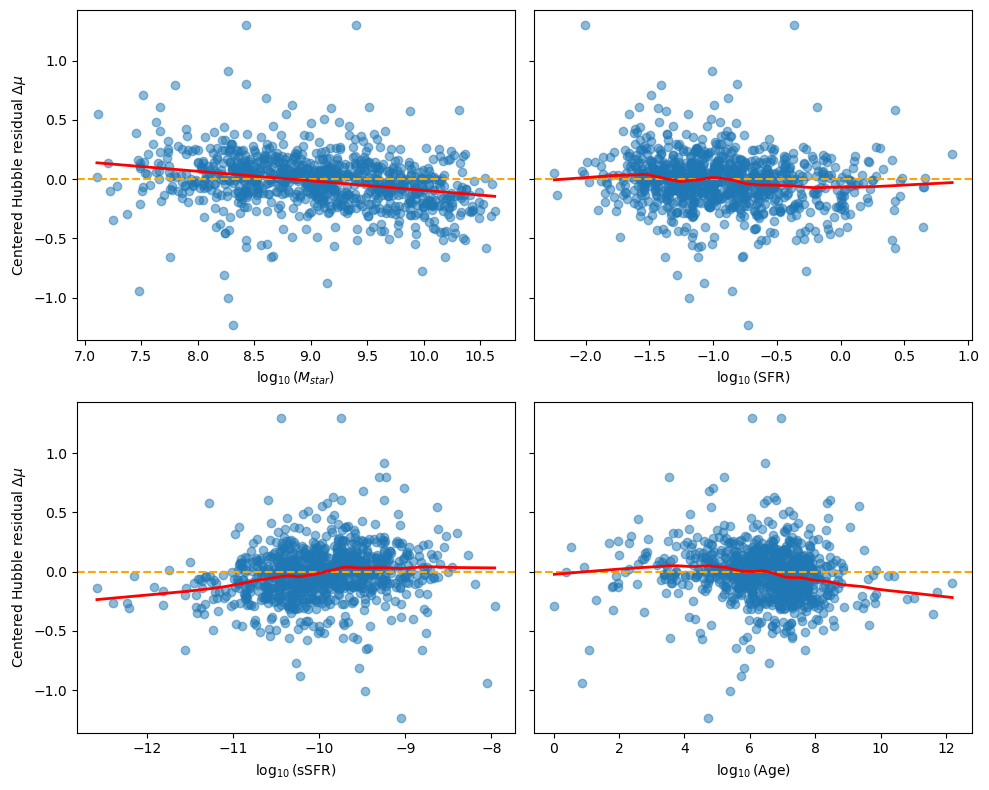

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr

# Load the merged file
df = pd.read_csv(
    "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_with_residuals.csv"
)

print(len(df), "SNe before applying quality cuts.")

# Keep only good-quality light curves + fits
df = df[(df["lccoverage_flag"] == 1) & (df["fitquality_flag"] == 1)] 
## Appplying quality cuts and flags to the data and stuff.

print(len(df), "SNe after applying quality cuts.")

# Convenience
lowess = sm.nonparametric.lowess

def add_lowess(ax, x, y, frac=0.3):
    """Add a LOWESS trend line to an axis."""
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        return None
    smoothed = lowess(y[mask], x[mask], frac=frac, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], linewidth=2, color="red", label="LOWESS")

def add_spearman(ax, x, y):
    """Compute Spearman correlation and annotate it."""
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        rho, pval = np.nan, np.nan
    else:
        rho, pval = spearmanr(x[mask], y[mask])
    ax.text(
        0.05, 0.95,
        f"ρ = {rho:.2f}\np = {pval:.2g}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )
    return rho, pval

# Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

# 1) residual_centered vs local log mass
ax = axes[0, 0]
x = df["blast_local_log_mass_50"].values
y = df["residual_centered"].values
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--", color="orange")

# --- Linear fit ---
a, b = np.polyfit(x, y, 1)   # slope, intercept
xline = np.linspace(np.min(x), np.max(x), 200)
yline = a * xline + b
ax.plot(xline, yline, color="red", linewidth=2, label="Linear Fit")

# Labels
ax.set_xlabel(r"$\log_{10} (M_{star})$")
ax.set_ylabel(r"Centered Hubble residual $\Delta \mu$")

# 2) residual_centered vs local log SFR
ax = axes[0, 1]
x = df["blast_local_log_sfr_50"]
y = df["residual_centered"]
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--", color="orange")
add_lowess(ax, x, y, frac=0.3)
ax.set_xlabel(r"$\log_{10} (\mathrm{SFR})$")

# 3) residual_centered vs local log sSFR
ax = axes[1, 0]
x = df["blast_local_log_ssfr_50"]
y = df["residual_centered"]
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--", color="orange")
add_lowess(ax, x, y, frac=0.3)
ax.set_xlabel(r"$\log_{10} (\mathrm{sSFR})$")
ax.set_ylabel(r"Centered Hubble residual $\Delta \mu$")

# 4) residual_centered vs local log age
ax = axes[1, 1]
x = df["blast_local_log_age_50"]
y = df["residual_centered"]
ax.scatter(x, y, alpha=0.5)
ax.axhline(0, linestyle="--", color="orange")
add_lowess(ax, x, y, frac=0.3)
ax.set_xlabel(r"$\log_{10} (\mathrm{Age})$")



plt.tight_layout()
plt.show()

(array([  2.,   1.,   0.,   2.,   0.,   2.,   1.,   2.,   1.,   3.,   5.,
         14.,  62., 293., 604., 195.,  44.,  16.,   8.,   9.,   4.,   3.,
          2.,   0.,   0.,   2.,   0.,   1.,   2.,   1.]),
 array([-3.70271314, -3.44620358, -3.18969401, -2.93318445, -2.67667489,
        -2.42016533, -2.16365577, -1.90714621, -1.65063665, -1.39412709,
        -1.13761752, -0.88110796, -0.6245984 , -0.36808884, -0.11157928,
         0.14493028,  0.40143984,  0.6579494 ,  0.91445897,  1.17096853,
         1.42747809,  1.68398765,  1.94049721,  2.19700677,  2.45351633,
         2.71002589,  2.96653546,  3.22304502,  3.47955458,  3.73606414,
         3.9925737 ]),
 <BarContainer object of 30 artists>)

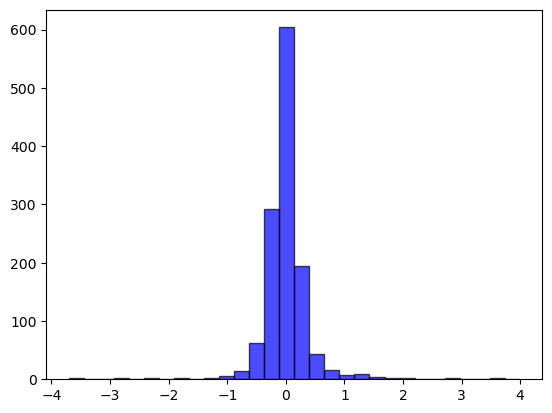

In [7]:
import matplotlib.pyplot as plt

plt.hist(df["residual_centered"], bins=30, alpha=0.7, color="blue", edgecolor="black")